# Different Families

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

import social_groups.polars_columns as plc
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations import (
    apply_parsing_and_group_decision,
)
from social_groups.analysis.polars_transformations.deserialize_experiment_configuration import (
    deserialize_experiment_configuration,
)
from social_groups.analysis.polars_transformations.make_group_constellation import (
    parse_model_family,
    parse_parameters,
)
from social_groups.analysis.polars_transformations.wasserstein_distance import (
    calculate_wasserstein_distance,
)
from social_groups.polars_values import MODEL_NAME_TO_LETTER_MAPPING
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)
from social_groups.reporting.plots.different_families.pareto_frontier_all_methods import (
    pareto_frontier_all_methods,
)
from social_groups.reporting.plots.different_families.plot_correlation_heatmaps import (
    plot_correlation_heatmaps,
)
from social_groups.reporting.plots.different_families.size_matched_plots import (
    plot_size_matched_performance,
    plot_size_matched_wd,
)

%load_ext autoreload
%autoreload 2

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:398: BetaWarning: Class `Manager` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  MANAGER_FOR_NOTEBOOK_INSTANCE = Manager()
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:180: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/src/social_groups/analysis/notebook_assets.py:185: BetaWarning: Class `LocalFileCodeReference` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  dg.LocalFileCodeReference(
/Users/philipp/Documents/Studium/Informatik/Masterth

In [2]:
parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling="wrong"
)

In [3]:
from social_groups.analysis.definitions import defs

different_families_mad: pl.DataFrame = defs().load_asset_value(
    "final_different_families"
)
baseline: pl.DataFrame = defs().load_asset_value("final_baseline")
homogeneous_mad: pl.DataFrame = defs().load_asset_value(
    ["report", "final_mad_baseline", "homogeneous_mad_big_subset_result"]
)

size_heterogeneous_mad: pl.DataFrame = defs().load_asset_value(
    ["report", "final_mad_baseline", "size_heterogeneous_mad_big_subset_result"]
)

no_discussion_voting_same_size_mixed_families: pl.DataFrame = defs().load_asset_value(
    [
        "report",
        "final_no_discussion_voting",
        "all_group_combinations_majority_voting_mixed_families",
    ]
)

no_discussion_voting_mixed_size_same_family: pl.DataFrame = defs().load_asset_value(
    ["report", "final_no_discussion_voting", "all_group_combinations_majority_voting"]
)

changed_order_mad: pl.DataFrame = defs().load_asset_value("final_changed_order_mad")

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_config/pythonic_config/typing_utils.py:101: UserWarning: Field name "extension" in "PolarsParquetIOManager" shadows an attribute in parent "BasePolarsUPathIOManager"
  return super().__new__(cls, name, bases, namespaces, **kwargs)
2026-06-21 22:19:30 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_different_families.parquet using PolarsParquetIOManager...
2026-06-21 22:19:31 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/final_baseline.parquet using PolarsParquetIOManager...
2026-06-21 22:19:32 +0200 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_mad_baseline/homogeneou

In [4]:
baseline_performance = (
    baseline.filter(pl.col("generation_method") == "standard")
    .filter(pl.col("with_few_shot_prompting") == True)
    .filter(pl.col("use_thinking") == True)
    .with_columns(
        comparer(parser(pl.col(plc.final_answer)), pl.col(plc.answer_string)).alias(
            plc.is_correct
        )
    )
    .group_by("model_name")
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        parse_model_family(pl.col("model_name")).alias(plc.model_family),
        pl.col("model_name")
        .replace(MODEL_NAME_TO_LETTER_MAPPING)
        .alias("model_letter"),
        call_cost_heuristic=parse_parameters(pl.col("model_name")) * 2,
    )
)

assert baseline_performance["len"].unique().item() == 1000

baseline_performance = baseline_performance.drop("len")

In [5]:
NUM_ROUNDS = different_families_mad["number_of_mad_rounds"].unique().item()


different_families_mad = apply_parsing_and_group_decision(
    different_families_mad, parser, comparer, group_reply
).with_columns(pl.col("sizes").list.eval(pl.element().str.replace("m", "M")))

In [6]:
no_discussion_voting_same_size_mixed_families = (
    no_discussion_voting_same_size_mixed_families.with_columns(
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2)
        .list.sum()
        * pl.col("no_participants")
        / pl.col("model_names").list.len()
    )
)

no_discussion_voting_mixed_size_same_family = (
    no_discussion_voting_mixed_size_same_family.with_columns(
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2)
        .list.sum()
        * pl.col("no_participants")
        / pl.col("model_names").list.len()
    )
)

In [7]:
different_families_mad_result = (
    different_families_mad.group_by(
        "sizes", "model_families", "model_parameters", "model_names"
    )
    .agg(
        pl.len(),
        pl.col(plc.is_correct).mean().alias(plc.accuracy),
        pl.col(plc.used_input_tokens).mean(),
        pl.col(plc.used_output_tokens).mean(),
        (
            pl.col("___parsed_individual_answers_after___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_after___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_after"),
        (
            pl.col("___parsed_individual_answers_before___").list.count_matches(
                "___not_parsable___"
            )
            / pl.col("___parsed_individual_answers_before___").list.len()
        )
        .mean()
        .alias("amount_parsing_errors_before"),
        comparer(
            pl.col(plc.parsed_combined_answers_before),
            pl.col(plc.answer_string),
        )
        .mean()
        .alias("accuracy_before"),
    )
    .sort(plc.accuracy, descending=True)
    .with_columns(
        call_cost_heuristic=pl.col("model_names")
        .list.eval(parse_parameters(pl.element()) * 2 * NUM_ROUNDS)
        .list.sum(),
        accuracy_increase=pl.col("accuracy") - pl.col("accuracy_before"),
        group_size=pl.col("sizes").list.len(),
    )
)

assert different_families_mad_result["len"].unique().item() == 1000

different_families_mad_result = different_families_mad_result.drop("len")

In [8]:
different_families_mad_wd = calculate_wasserstein_distance(
    different_families_mad, group_reply, comparer, "run_id"
).drop("run_id", "run_identifier", "number_of_mad_rounds", "accuracy_increase_percent")

different_families_mad_results_combined = different_families_mad_result.join(
    different_families_mad_wd,
    on=[
        "model_names",
        "model_families",
        "model_parameters",
        "sizes",
        "accuracy",
        "accuracy_before",
        "accuracy_increase",
    ],
    validate="1:1",
    # suffix=""
).with_columns(
    parameter_spread=(
        pl.col("model_parameters").list.max() - pl.col("model_parameters").list.min()
    ),
    size_group=pl.col("sizes")
    .list.eval(pl.element().str.tail(1))
    .list.unique()
    .list.item(),
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_different_families/pareto_frontier_all_methods.png


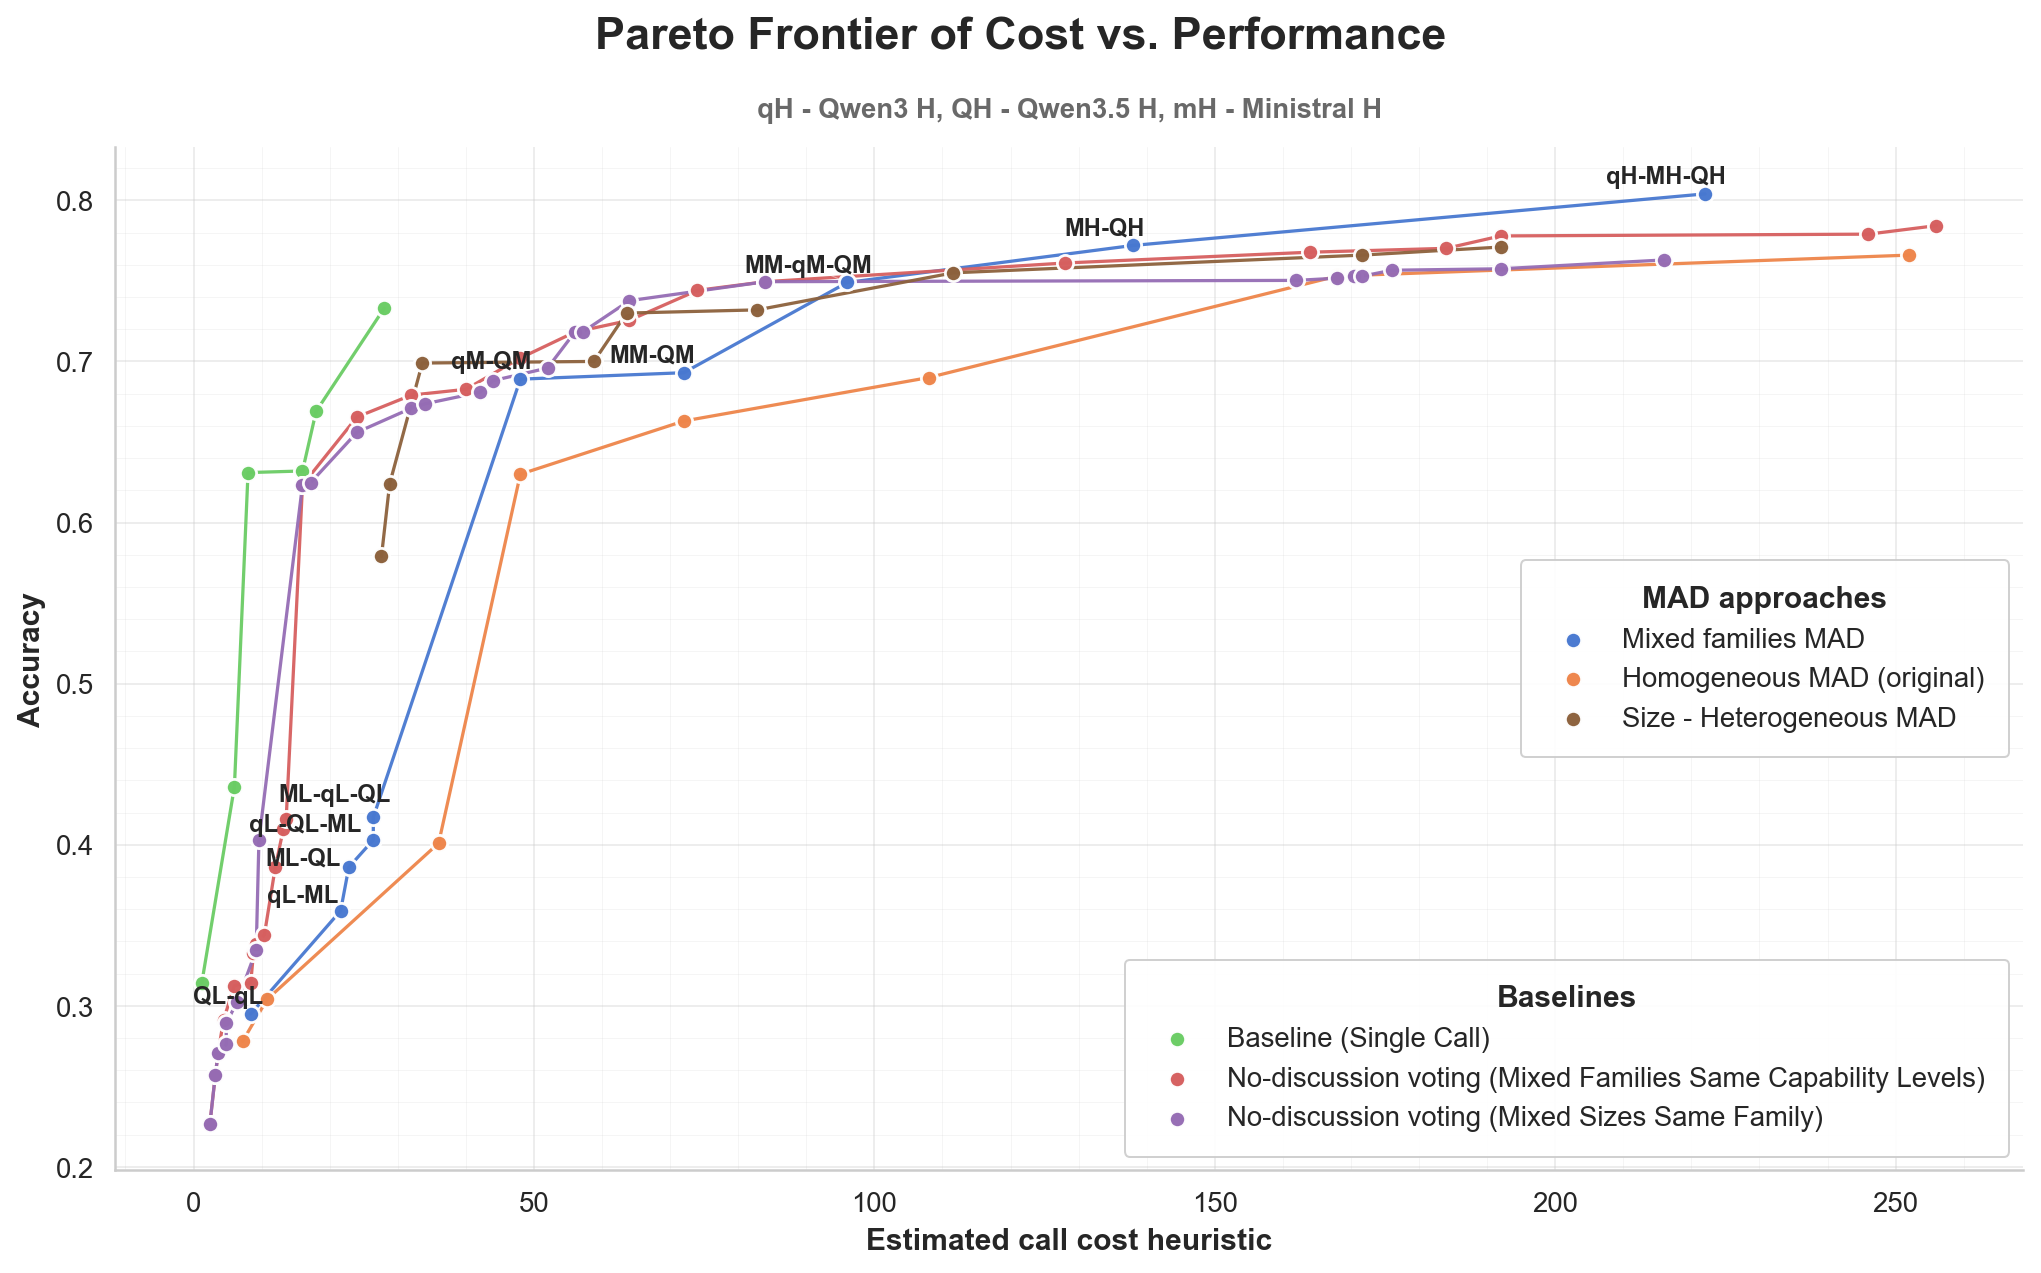

In [24]:
register_materialization(
    "pareto_frontier_all_methods",
    pareto_frontier_all_methods(
        different_families_mad_results_combined,
        homogeneous_mad,
        baseline_performance,
        no_discussion_voting_same_size_mixed_families,
        no_discussion_voting_mixed_size_same_family,
        size_heterogeneous_mad,
    ),
    "pareto frontier with several methods on big subset MMLUPro (1000)",
    force=True,
)

In [10]:
homo_mad_with_wd = calculate_wasserstein_distance(
    apply_parsing_and_group_decision(
        changed_order_mad.filter(
            pl.col("group_constellation").str.split("").list.unique().list.len() == 1
        ),
        parser,
        comparer,
        group_reply,
    ),
    group_reply,
    comparer,
    "run_id",
).drop(
    [
        "run_id",
        "message_ids",
        "run_identifier",
        "final_answer",
        "experiment_id",
        "experiment_configuration_json",
        "execution_config_json",
        "meta_info_json",
        "name",
        "data_connector",
        "accuracy_increase_percent",
    ]
)

diff_family_mad_with_wd = different_families_mad_results_combined.drop(
    [
        "used_input_tokens",
        "used_output_tokens",
        "amount_parsing_errors_after",
        "amount_parsing_errors_before",
        "call_cost_heuristic",
        "group_size",
    ]
)

In [11]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="muted",
    font_scale=1.25,
)

plt.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

WD_COLS = [
    "wd_bias_good proposals",
    "wd_bias_bad proposals",
    "wd_bias_weight on one",
    "wd_bias_False",
]

PERF_COLS = [
    "accuracy_before",
    "accuracy",
    "accuracy_increase",
]

ALL_METRICS = PERF_COLS + WD_COLS

In [16]:
def prepare_comparison_df(
    homo_mad_with_wd: pl.DataFrame, diff_family_mad_with_wd: pl.DataFrame
) -> pd.DataFrame:
    homo = homo_mad_with_wd.with_columns(
        [
            pl.lit("Homogeneous family").alias("composition_type"),
            pl.col("group_constellation")
            .str.split("")
            .list.unique()
            .list.item()
            .alias("size_level"),
        ]
    ).select(["composition_type", "size_level"] + ALL_METRICS)

    diff = diff_family_mad_with_wd.with_columns(
        [
            pl.lit("Diverse families").alias("composition_type"),
            pl.col("size_group").alias("size_level"),
        ]
    ).select(["composition_type", "size_level"] + ALL_METRICS)

    df = pl.concat([homo, diff]).to_pandas()

    df["size_level"] = pd.Categorical(
        df["size_level"],
        categories=["L", "M", "H"],
        ordered=True,
    )

    df["composition_type"] = pd.Categorical(
        df["composition_type"],
        categories=["Homogeneous family", "Diverse families"],
        ordered=True,
    )

    return df


comparison_df = prepare_comparison_df(
    homo_mad_with_wd,
    diff_family_mad_with_wd,
)

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_different_families/plot_size_matched_performance.png


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


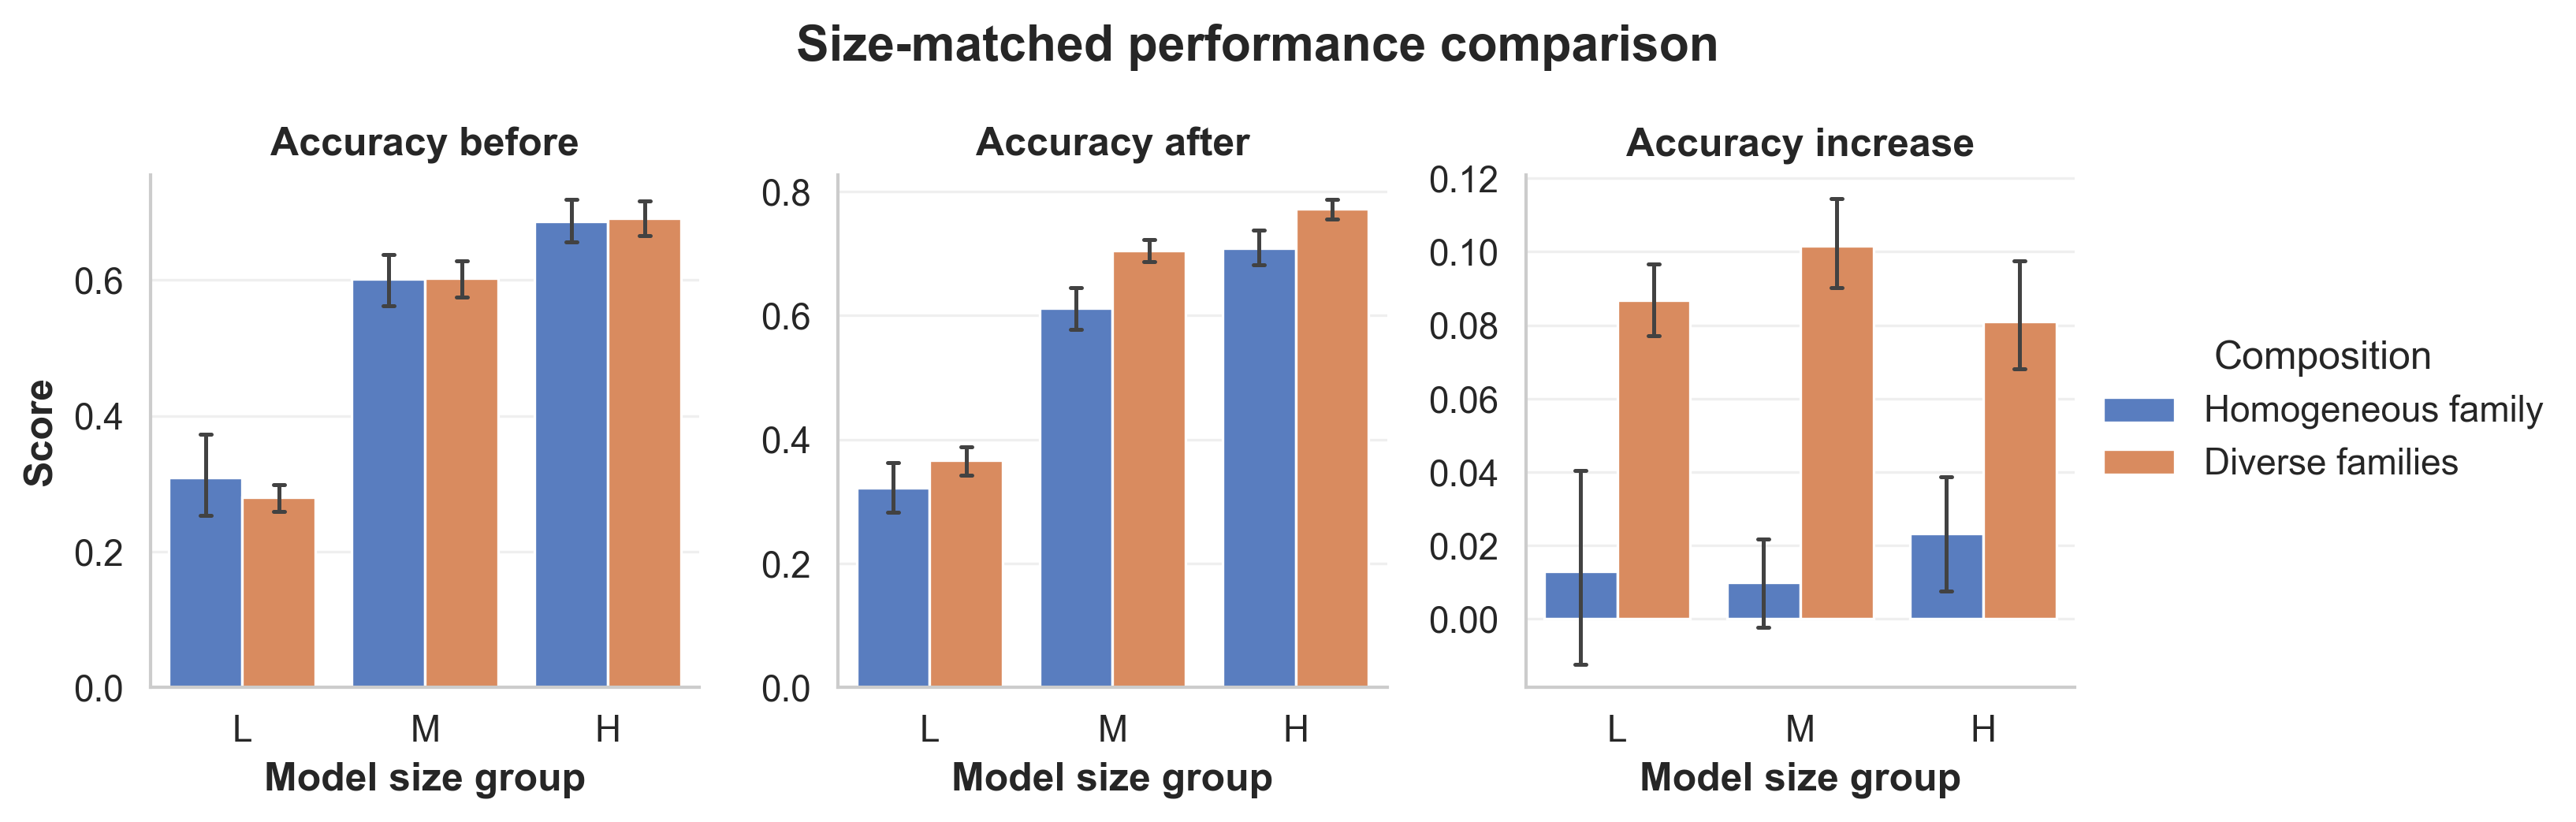

In [19]:
register_materialization(
    "plot_size_matched_performance",
    plot_size_matched_performance(comparison_df, PERF_COLS),
    "plot_size_matched_performance between homogeneous vs family-heterogeneous MAD",
    force=True,
)

/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_different_families/plot_size_matched_wd.png


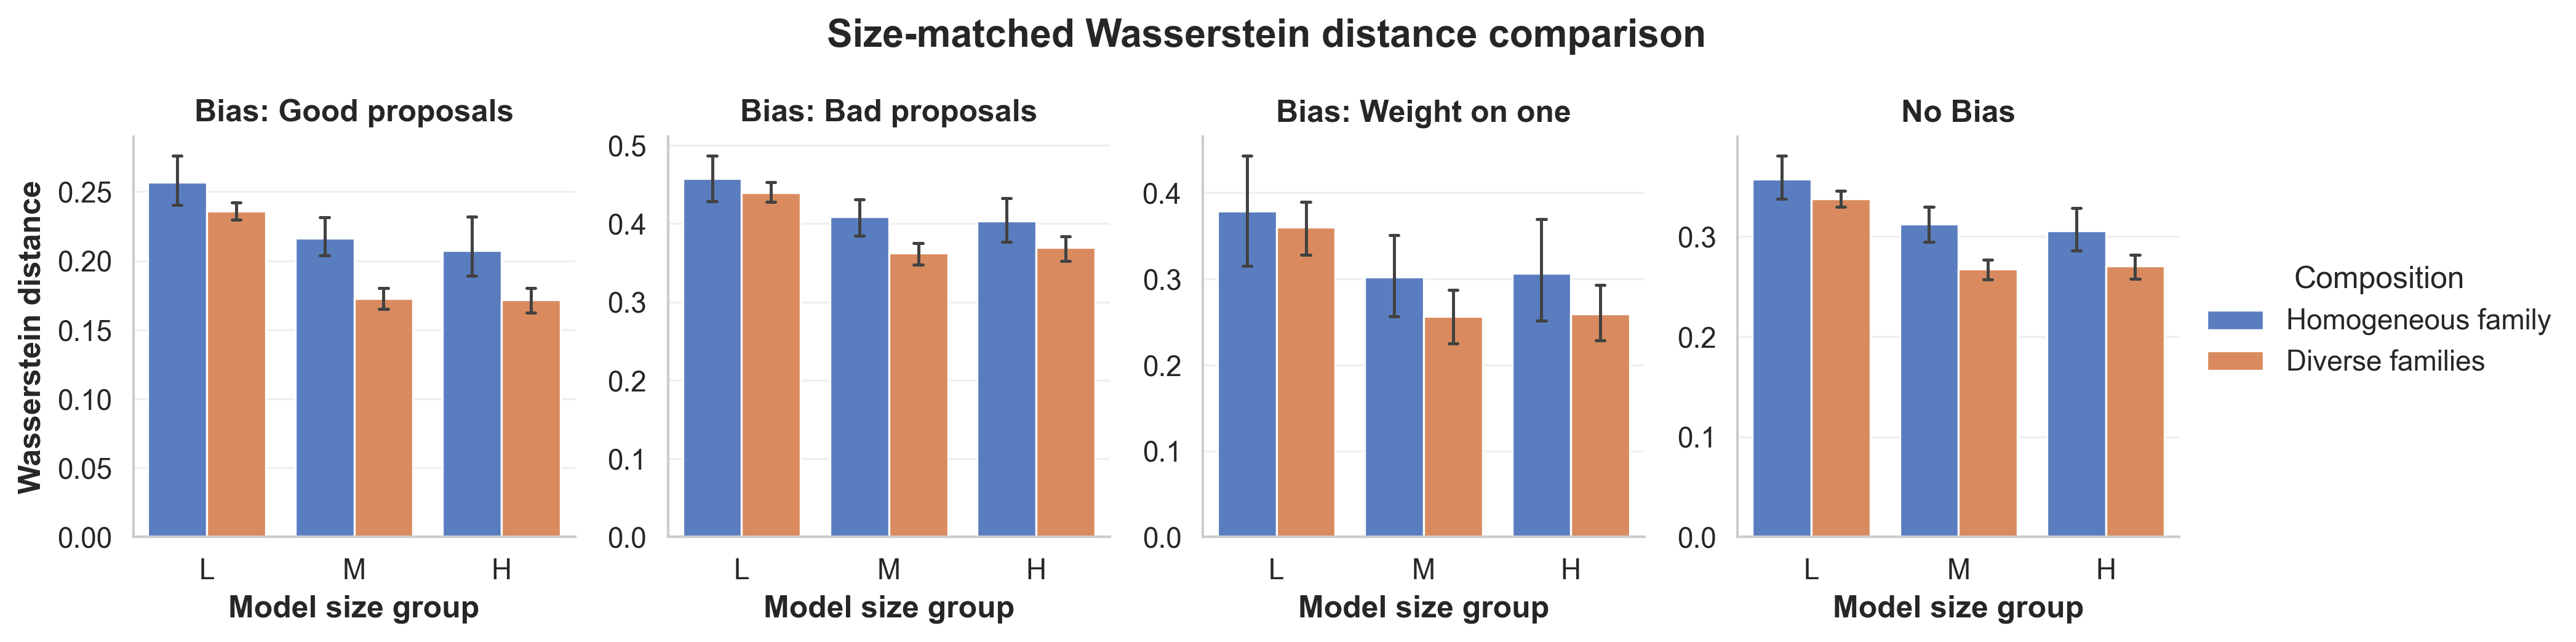

In [20]:
register_materialization(
    "plot_size_matched_wd",
    plot_size_matched_wd(comparison_df, WD_COLS),
    "plot_size_matched_wd between homogeneous vs family-heterogeneous MAD",
    force=True,
)

Wrote to:  /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/report/final_different_families/plot_correlation_heatmaps.png


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(


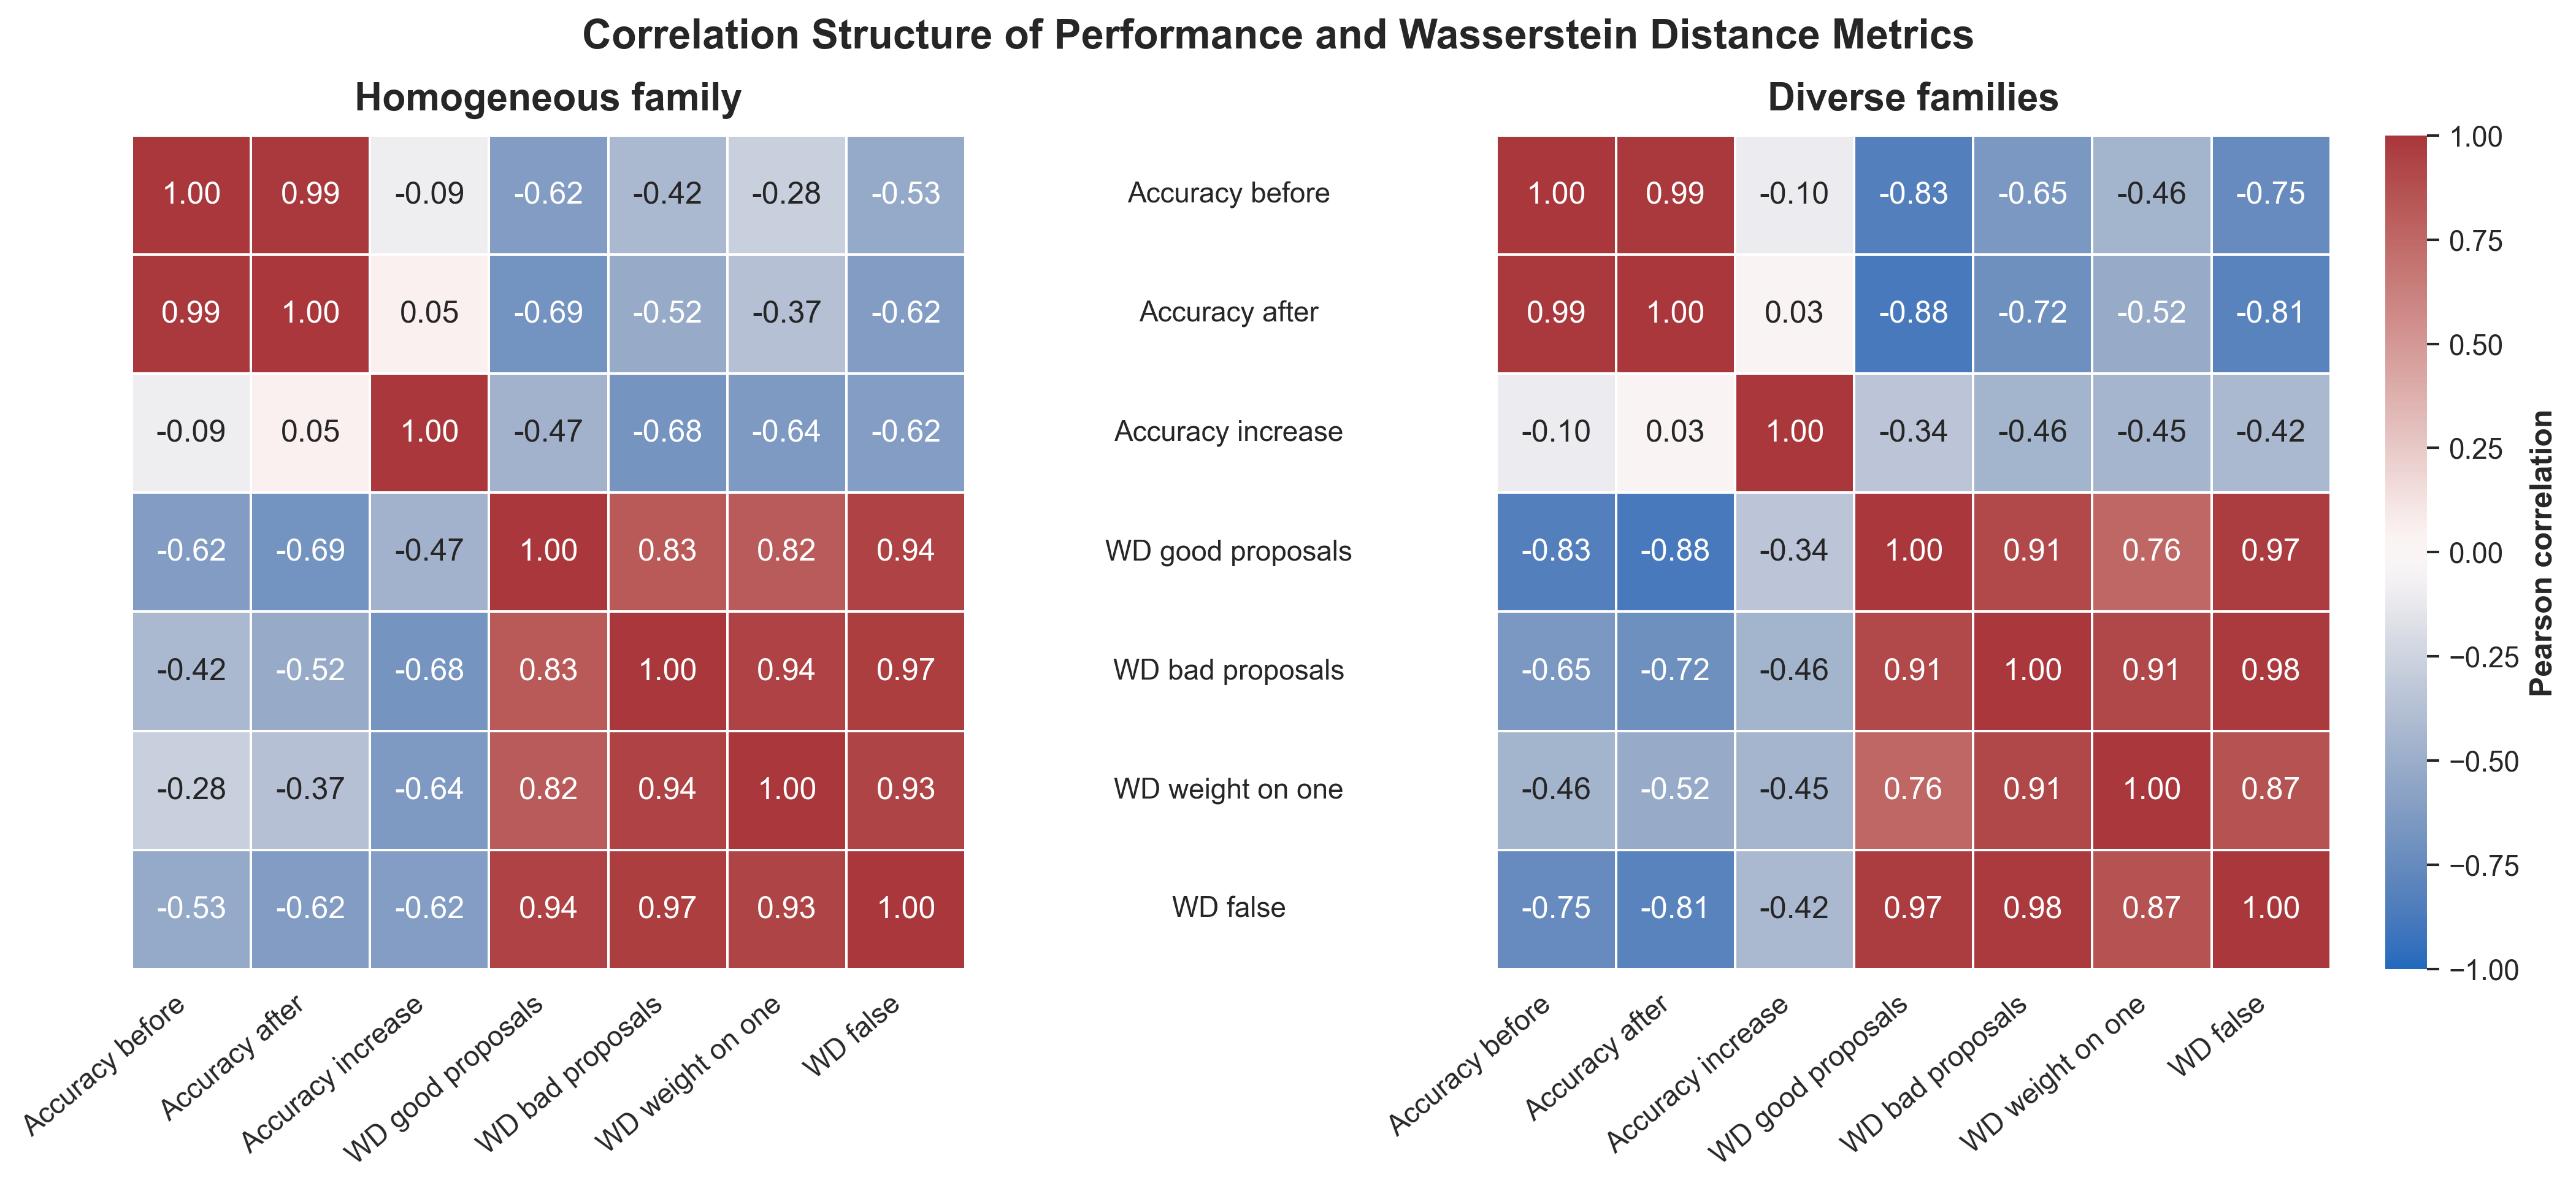

In [21]:
register_materialization(
    "plot_correlation_heatmaps",
    plot_correlation_heatmaps(comparison_df),
    "plot_correlation_heatmaps between homogeneous vs family-heterogeneous MAD",
    force=True,
)